<a href="https://colab.research.google.com/github/jawadAlishafaqat/Bike-Demand-Prediction-using-Ridge-Regression/blob/main/Ridge_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df=pd.read_csv("/content/hour.csv")

In [6]:
df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [7]:
df.isnull().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.drop_duplicates(inplace=True)

In [10]:
df.drop(["instant", "dteday", "casual", "registered"], axis=1, inplace=True)

In [11]:
df["rush_hour"] = df["hr"].apply(
    lambda x: 1 if (7 <= x <= 9) or (17 <= x <= 19) else 0
)

df["is_weekend"] = df["weekday"].apply(
    lambda x: 1 if x in [0, 6] else 0
)

df["temp_humidity"] = df["temp"] * df["hum"]

In [12]:
X = df.drop("cnt", axis=1)
y = df["cnt"]

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [15]:
from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_train, y_train)

Ridge()

In [16]:
y_pred = ridge_model.predict(X_test)

In [17]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

print("R2 Score:", r2_score(y_test, y_pred))

print("MAE:", mean_absolute_error(y_test, y_pred))

print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2 Score: 0.5697472705876816
MAE: 87.70984286402657
RMSE: 116.72244709341162


In [18]:
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
12830,425,615.788968
8688,88,131.187251
7091,4,30.795488
12230,526,511.056398
431,13,-50.383342
1086,32,-15.727560
11605,706,466.953501
7983,26,195.827991
10391,2,91.938427
7046,21,68.180299


In [19]:
y_pred = np.maximum(y_pred, 0)

In [20]:
y_pred = ridge_model.predict(X_test)

y_pred = np.maximum(y_pred, 0)

In [21]:
print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2 Score: 0.5758275384492535
MAE: 85.46754030004101
RMSE: 115.89476033281989


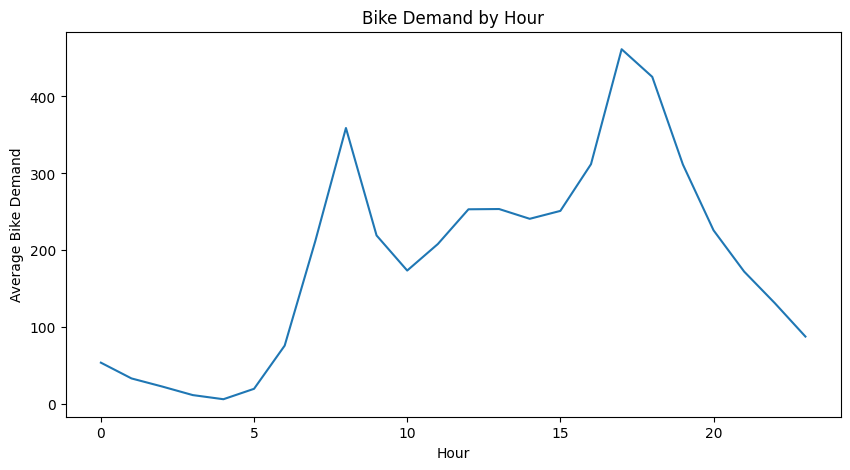

In [22]:
import matplotlib.pyplot as plt

hourly_demand = df.groupby("hr")["cnt"].mean()

plt.figure(figsize=(10,5))
plt.plot(hourly_demand.index, hourly_demand.values)

plt.xlabel("Hour")
plt.ylabel("Average Bike Demand")
plt.title("Bike Demand by Hour")

plt.show()

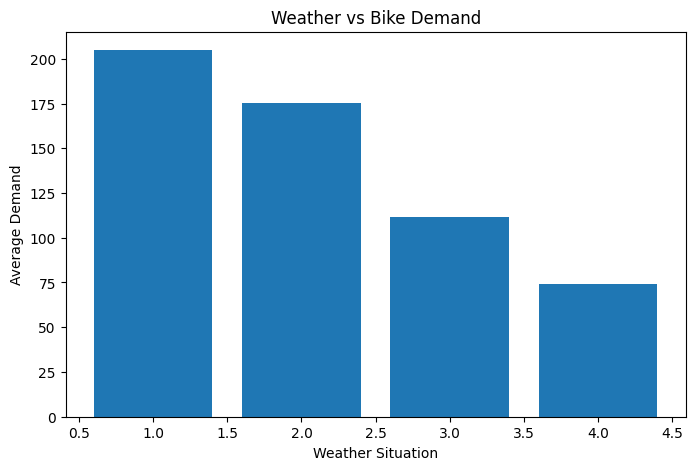

In [23]:
weather_demand = df.groupby("weathersit")["cnt"].mean()

plt.figure(figsize=(8,5))
plt.bar(weather_demand.index, weather_demand.values)

plt.xlabel("Weather Situation")
plt.ylabel("Average Demand")
plt.title("Weather vs Bike Demand")

plt.show()

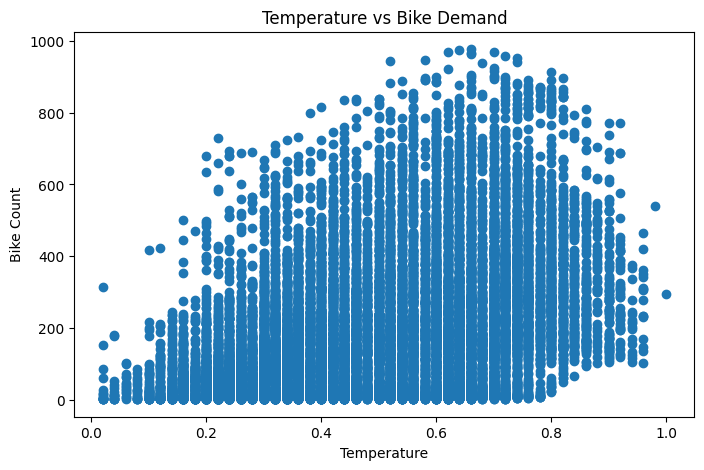

In [24]:
plt.figure(figsize=(8,5))

plt.scatter(df["temp"], df["cnt"])

plt.xlabel("Temperature")
plt.ylabel("Bike Count")
plt.title("Temperature vs Bike Demand")

plt.show()

In [25]:
import joblib

joblib.dump(ridge_model, "ridge_model.pkl")

['ridge_model.pkl']

In [26]:
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']